In [1]:
import os
import glob
from source.dataset import CombinedDataset
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pt_files = glob.glob(os.path.join("data/pt_std_nolog/10002", "*.pt"))
targets = {"E_nu": [], "E_vis": [], "pT_miss": [], "pT_lep": [], "pT_jet": [], "p_jet": [], "p_lep": [], "E_lep": []}

In [3]:
dataloader = CombinedDataset(pt_files)

In [4]:
for event in tqdm(dataloader):
    for key in targets.keys():
        targets[key].append(event[key].item())
targets = {k: np.asarray(v) for k, v in targets.items()}

100%|██████████| 85927/85927 [00:01<00:00, 70209.62it/s]


In [5]:
print(targets["E_nu"])

[-1.27907658  0.76093042 -0.88948774 ...  1.20625377  0.94586468
  0.28270325]


In [6]:
print(targets["p_lep"])

[-0.93008792  0.72388273 -0.94775236 ...  2.29668283  0.7971527
  0.21952254]


In [7]:


def plot_pairwise_2dhists(targets, bins=50, cmap="viridis"):
    keys = list(targets.keys())
    n = len(keys)

    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    
    # Convert to numpy arrays
    data = {k: np.asarray(v) for k, v in targets.items()}

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i < j:
                # Upper triangle: turn off
                ax.axis("off")
                continue

            x = data[keys[j]]
            y = data[keys[i]]

            if i == j:
                # Diagonal: 1D histogram
                ax.hist(x, bins=bins, histtype="stepfilled", alpha=0.7)
            else:
                # Lower triangle: 2D histogram
                h = ax.hist2d(x, y, bins=bins, cmap=cmap)

            # Labels only on outer axes
            if i == n - 1:
                ax.set_xlabel(f"Log10 {keys[j]}")
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(f"Log10 {keys[i]}")
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    return fig, axes

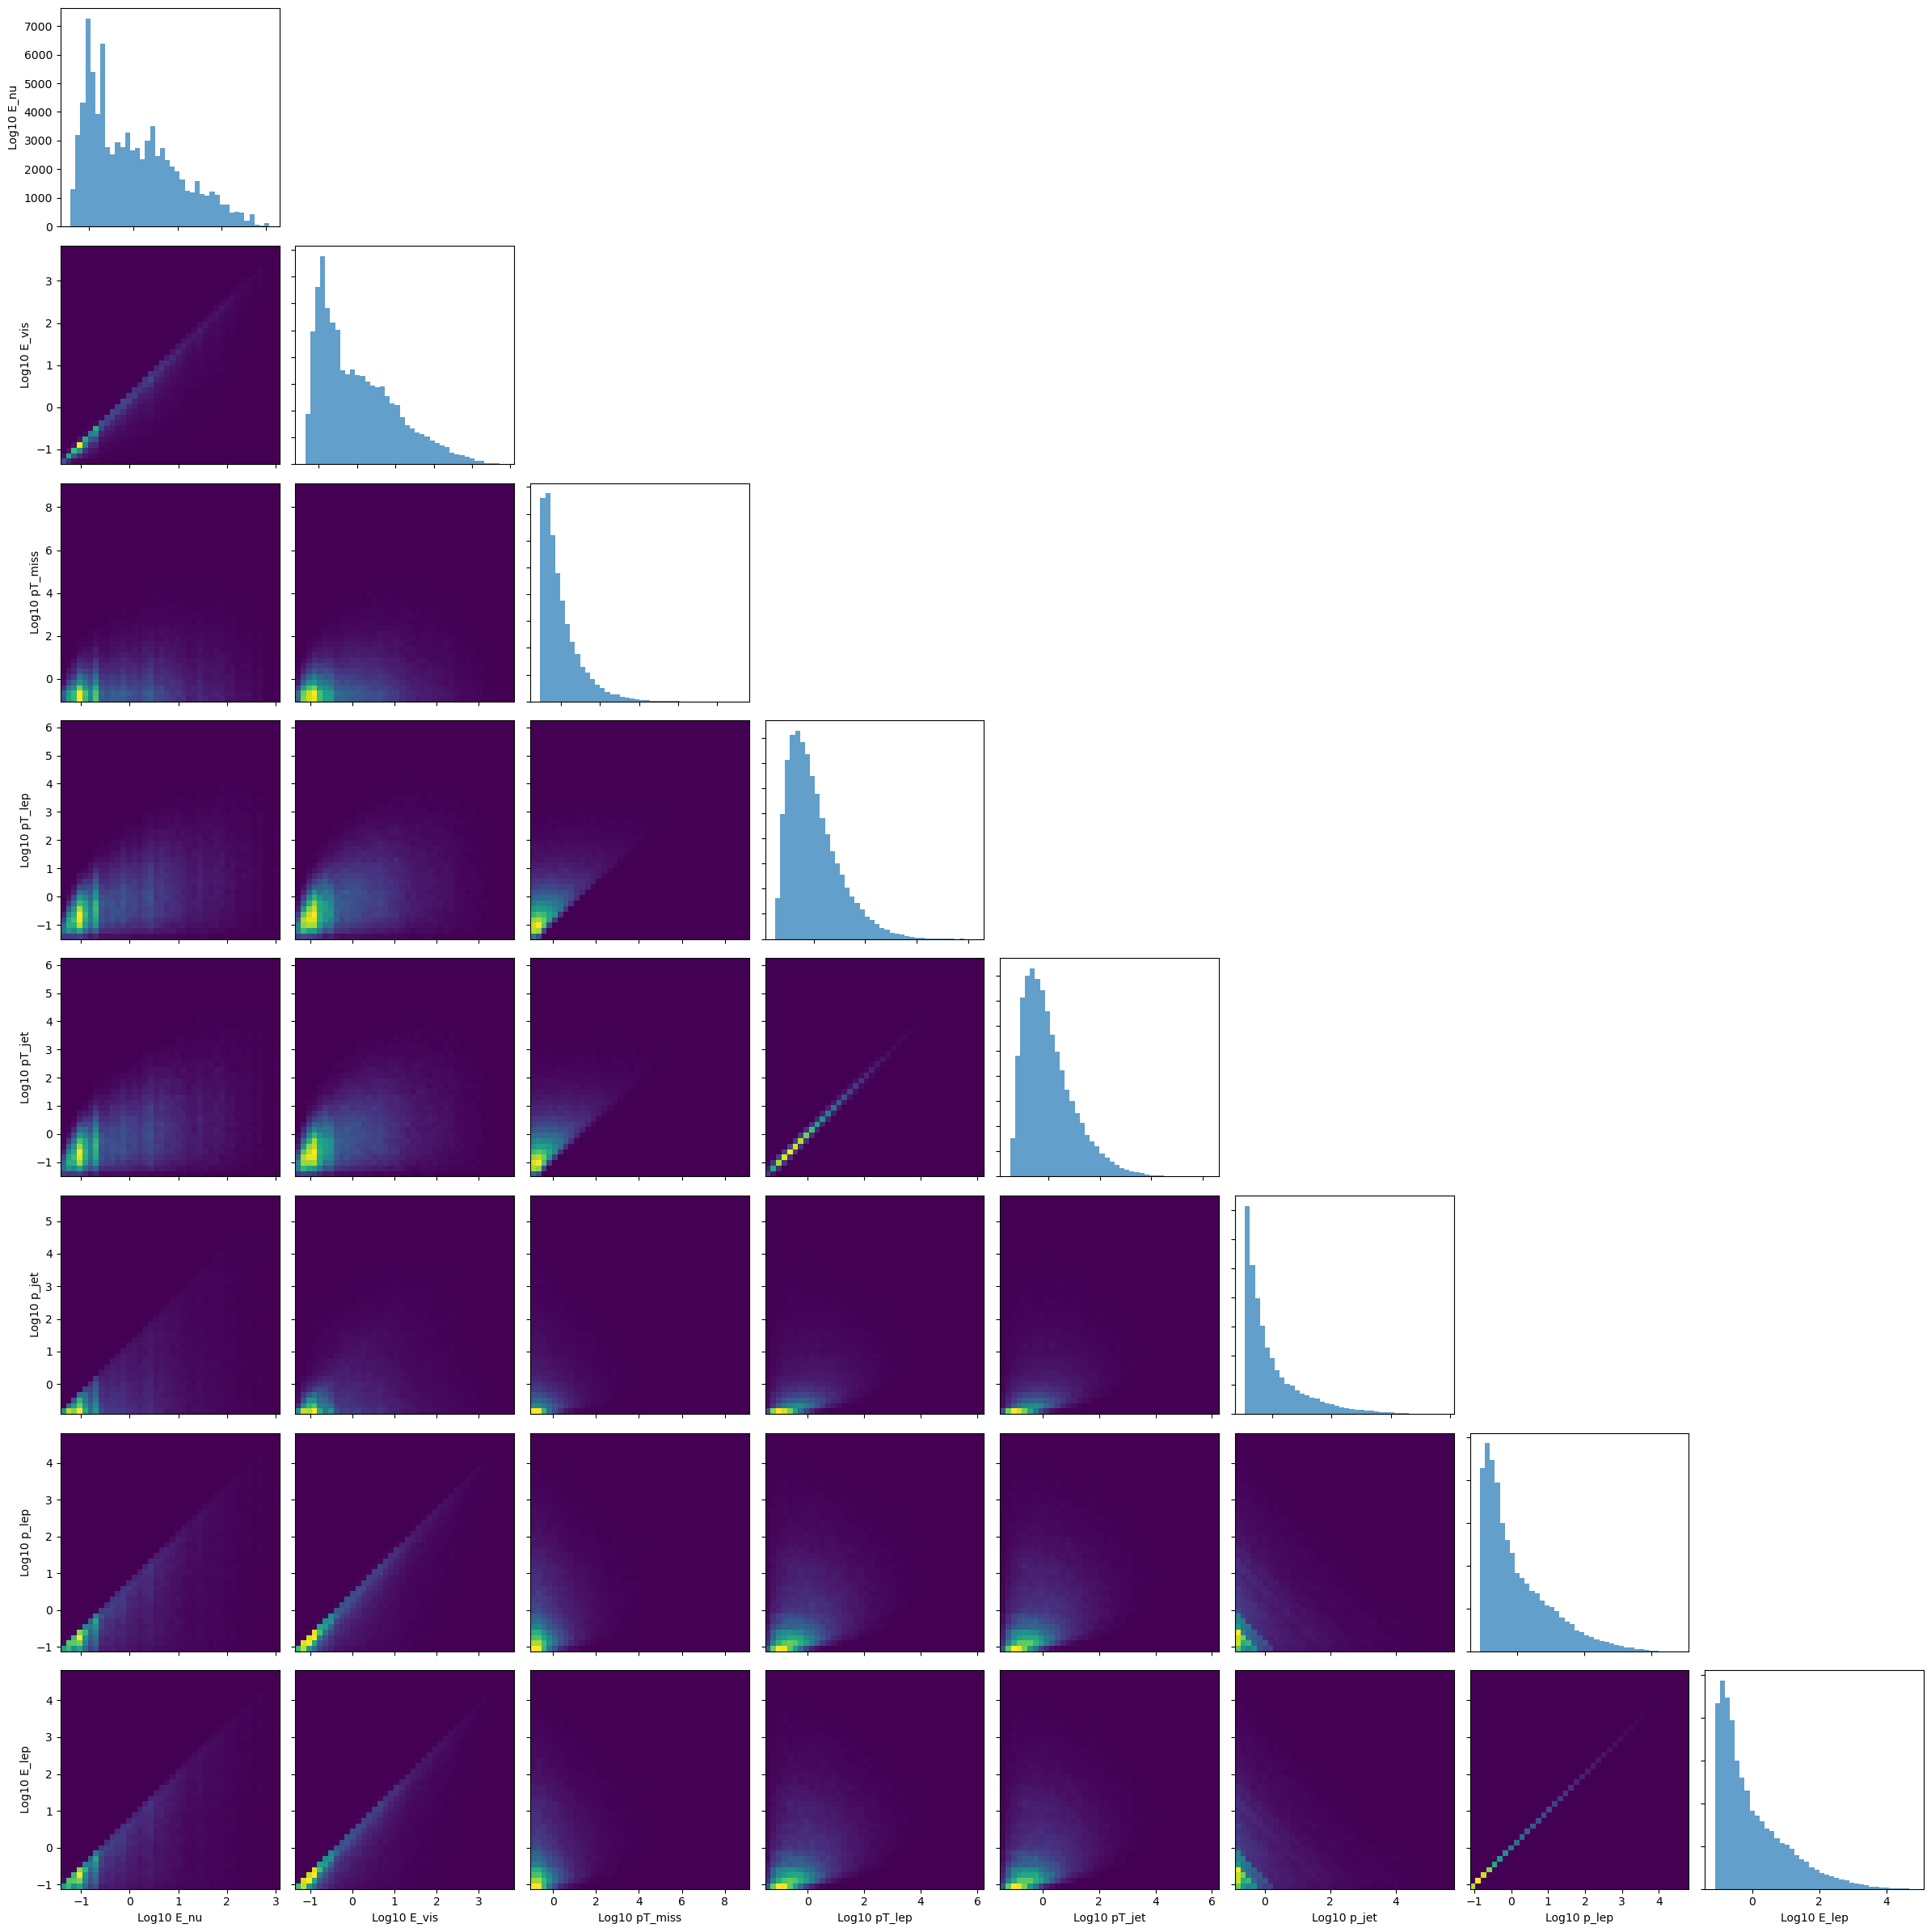

In [8]:
fig, axes = plot_pairwise_2dhists(targets, bins=40)
plt.show()

In [9]:
for var_name, values in targets.items():
    mean = np.mean(values)
    std = np.std(values)
    print(f"{var_name}:")
    print(f"\tmean: {mean:.3f}")
    print(f"\tstd: {std:.3f}")

E_nu:
	mean: 0.003
	std: 0.993
E_vis:
	mean: 0.007
	std: 0.997
pT_miss:
	mean: 0.007
	std: 0.992
pT_lep:
	mean: 0.006
	std: 0.985
pT_jet:
	mean: 0.006
	std: 0.985
p_jet:
	mean: 0.004
	std: 0.995
p_lep:
	mean: 0.000
	std: 0.998
E_lep:
	mean: 0.000
	std: 0.998
